**DATA ANALYSIS WITH PANDAS**

INSTALL LIBRARIES

In [ ]:
import sys
!{sys.executable} -m pip install --upgrade matplotlib pandas

IMPORT LIBRARIES

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

READ DATA WITH PANDAS

In [ ]:
df = pd.read_csv("data\sales.csv", encoding="utf-8", header=0 )
df.info()

PANDAS SETTINGS

In [ ]:
df.Date = pd.to_datetime(df.Date, format='%d-%m-%Y') #Make date column to datetime instead of str. Giving the date format of the csv
print (df.Date.dtype)
pd.set_option('display.float_format', lambda x: '{:,.2f}' .format(x))

Create Year, Day and Month columns to work with

In [ ]:
df['Month'] = df.Date.dt.month
df['Year'] = df.Date.dt.year

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11,Friday,2,2010
1,1,2010-02-12,"1,641,957.44",1,38.51,2.55,211.24,8.11,Friday,2,2010
2,1,2010-02-19,"1,611,968.17",0,39.93,2.51,211.29,8.11,Friday,2,2010
3,1,2010-02-26,"1,409,727.59",0,46.63,2.56,211.32,8.11,Friday,2,2010
4,1,2010-03-05,"1,554,806.68",0,46.50,2.62,211.35,8.11,Friday,3,2010


**ANALYSIS**

Monthly Sales

Month
1    332,598,438.49
2    568,727,890.45
3    592,785,901.28
4    646,859,784.97
5    557,125,571.95
6    622,629,886.84
7    650,000,977.25
8    613,090,208.82
9    578,761,179.26
10   584,784,787.59
11   413,015,725.01
12   576,838,635.20
Name: Weekly_Sales, dtype: float64


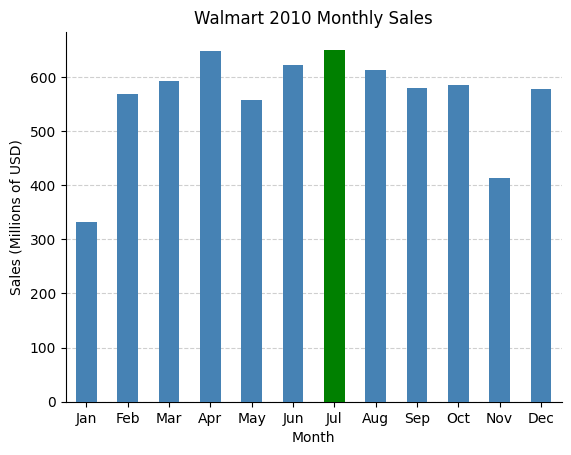

In [44]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].sum()  # group the sales by month and return the total
top_month = monthly_sales.max()  
worst_month = monthly_sales.min()
month_names=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(monthly_sales)

# Graph
colors = ['green' if v == top_month else 'steelblue' for v in monthly_sales]
(monthly_sales/1000000).plot(kind='bar', title='Walmart 2010 Monthly Sales', ylabel='Sales (Millions of USD)', color=colors, zorder=4)
plt.xticks(range(12), month_names, rotation=0)  # show month names
plt.grid(axis='y', linestyle='--', alpha=0.6, zorder=1)  # grid settings
plt.gca().spines['top'].set_visible(False) # spines visibility
plt.gca().spines['right'].set_visible(False)